In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ddm(v, sigma=0.3, boundary=1.0, dt=0.01, max_time=5.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    t = 0.0
    x = 0.0  # start with no evidence accumulated yet, right in the middle
    x_trace = [x]
    t_trace = [t]

    while abs(x) < boundary and t < max_time:
        dx = v * dt + sigma * np.sqrt(dt) * np.random.randn()
        x = x + dx
        t = t + dt
        x_trace.append(x)
        t_trace.append(t)

    decision = "right" if x >= boundary else "left"
    return np.array(t_trace), np.array(x_trace), decision, t

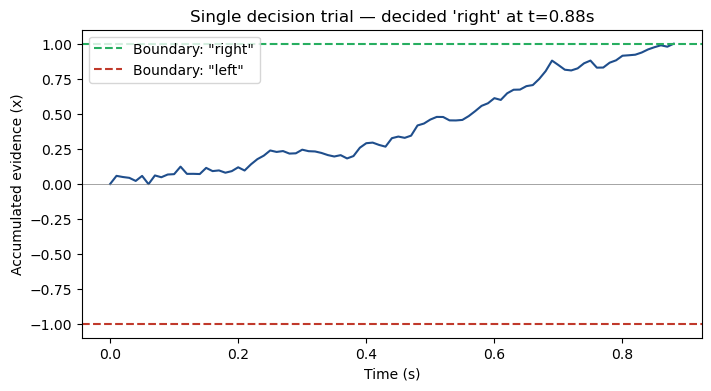

In [3]:
t_trace, x_trace, decision, rt = simulate_ddm(v=1.0, seed=1)

plt.figure(figsize=(8,4))
plt.plot(t_trace, x_trace, color='#1f4e8c')
plt.axhline(1.0, color='#27ae60', linestyle='--', label='Boundary: "right"')
plt.axhline(-1.0, color='#c0392b', linestyle='--', label='Boundary: "left"')
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Accumulated evidence (x)")
plt.title(f"Single decision trial — decided '{decision}' at t={rt:.2f}s")
plt.legend()
plt.show()

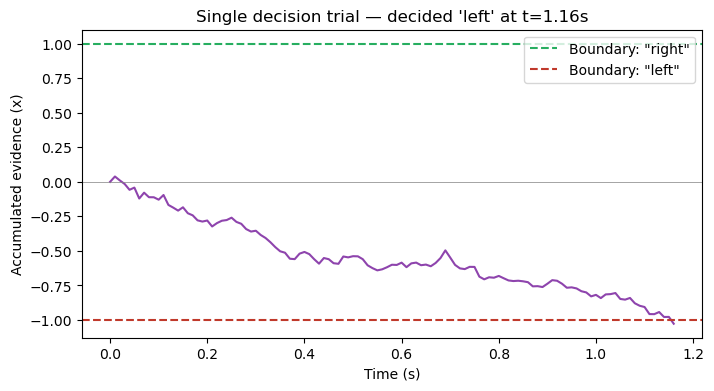

In [4]:
t_trace_L, x_trace_L, decision_L, rt_L = simulate_ddm(v=-1.0, seed=1)

plt.figure(figsize=(8,4))
plt.plot(t_trace_L, x_trace_L, color='#8e44ad')
plt.axhline(1.0, color='#27ae60', linestyle='--', label='Boundary: "right"')
plt.axhline(-1.0, color='#c0392b', linestyle='--', label='Boundary: "left"')
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Accumulated evidence (x)")
plt.title(f"Single decision trial — decided '{decision_L}' at t={rt_L:.2f}s")
plt.legend()
plt.show()

In [5]:
def run_many_trials(v, n_trials=200, sigma=0.3, boundary=1.0, dt=0.01, max_time=5.0):
    decisions = []
    rts = []
    for i in range(n_trials):
        _, _, decision, rt = simulate_ddm(v, sigma, boundary, dt, max_time, seed=i)
        decisions.append(decision)
        rts.append(rt)
    accuracy = np.mean([d == "right" for d in decisions])  # "right" is the correct answer when v > 0
    mean_rt = np.mean(rts)
    return accuracy, mean_rt, rts

drift_rates = [0.2, 0.5, 1.0, 2.0]
accuracies = []
mean_rts = []

for v in drift_rates:
    acc, mrt, rts = run_many_trials(v)
    accuracies.append(acc)
    mean_rts.append(mrt)
    print(f"v={v}: accuracy={acc:.2%}, mean RT={mrt:.3f}s")

v=0.2: accuracy=64.00%, mean RT=3.742s
v=0.5: accuracy=99.00%, mean RT=1.925s
v=1.0: accuracy=100.00%, mean RT=1.031s
v=2.0: accuracy=100.00%, mean RT=0.515s


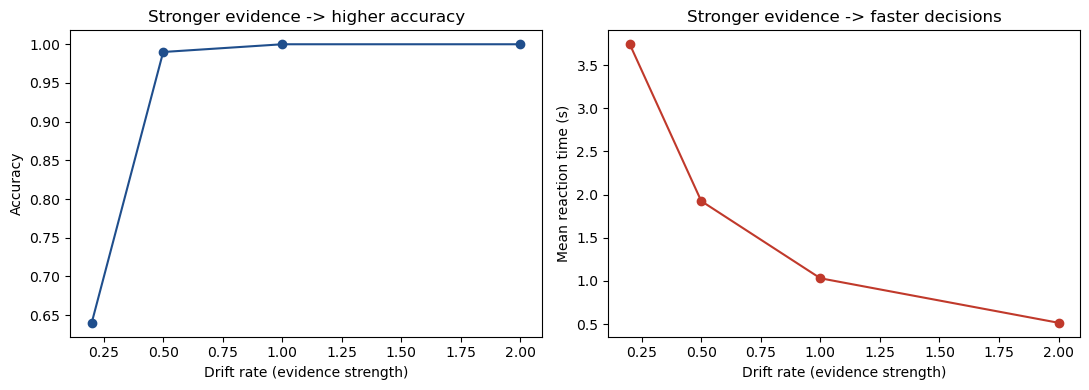

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(drift_rates, accuracies, marker='o', color='#1f4e8c')
axes[0].set_xlabel("Drift rate (evidence strength)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Stronger evidence -> higher accuracy")

axes[1].plot(drift_rates, mean_rts, marker='o', color='#c0392b')
axes[1].set_xlabel("Drift rate (evidence strength)")
axes[1].set_ylabel("Mean reaction time (s)")
axes[1].set_title("Stronger evidence -> faster decisions")

plt.tight_layout()
plt.show()

In [7]:
def simulate_ddm_biased(v, x0=0.0, sigma=0.3, boundary=1.0, dt=0.01, max_time=5.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    t = 0.0
    x = x0
    x_trace = [x]
    t_trace = [t]

    while abs(x) < boundary and t < max_time:
        dx = v * dt + sigma * np.sqrt(dt) * np.random.randn()
        x = x + dx
        t = t + dt
        x_trace.append(x)
        t_trace.append(t)

    decision = "right" if x >= boundary else "left"
    return np.array(t_trace), np.array(x_trace), decision, t

In [8]:
np.random.seed(0)

# Neutral evidence (v near zero genuinely ambiguous), but starting already biased toward "right"
n_trials = 200
biases = [0.0, 0.3, 0.6, 0.9]  # 0.0 = neutral start, 0.9 = very close to the "right" boundary already

for x0 in biases:
    decisions = []
    for i in range(n_trials):
        _, _, decision, rt = simulate_ddm_biased(v=0.05, x0=x0, seed=i)  # v=0.05: almost no real signal
        decisions.append(decision)
    pct_right = np.mean([d == "right" for d in decisions])
    print(f"Starting bias x0={x0}: chose 'right' {pct_right:.1%} of the time")

Starting bias x0=0.0: chose 'right' 22.0% of the time
Starting bias x0=0.3: chose 'right' 40.0% of the time
Starting bias x0=0.6: chose 'right' 71.0% of the time
Starting bias x0=0.9: chose 'right' 91.5% of the time


In [9]:
np.random.seed(0)

n_trials = 200
x0 = 0.9  # strong prior bias toward "right"
contrary_drift_rates = [-0.1, -0.3, -0.6, -1.0, -1.5]  # increasingly strong evidence AGAINST the bias

for v in contrary_drift_rates:
    decisions = []
    for i in range(n_trials):
        _, _, decision, rt = simulate_ddm_biased(v=v, x0=x0, seed=i)
        decisions.append(decision)
    pct_left = np.mean([d == "left" for d in decisions])
    print(f"Contrary evidence v={v}: changed mind to 'left' {pct_left:.1%} of the time")

Contrary evidence v=-0.1: changed mind to 'left' 28.5% of the time
Contrary evidence v=-0.3: changed mind to 'left' 56.0% of the time
Contrary evidence v=-0.6: changed mind to 'left' 78.0% of the time
Contrary evidence v=-1.0: changed mind to 'left' 92.0% of the time
Contrary evidence v=-1.5: changed mind to 'left' 97.0% of the time


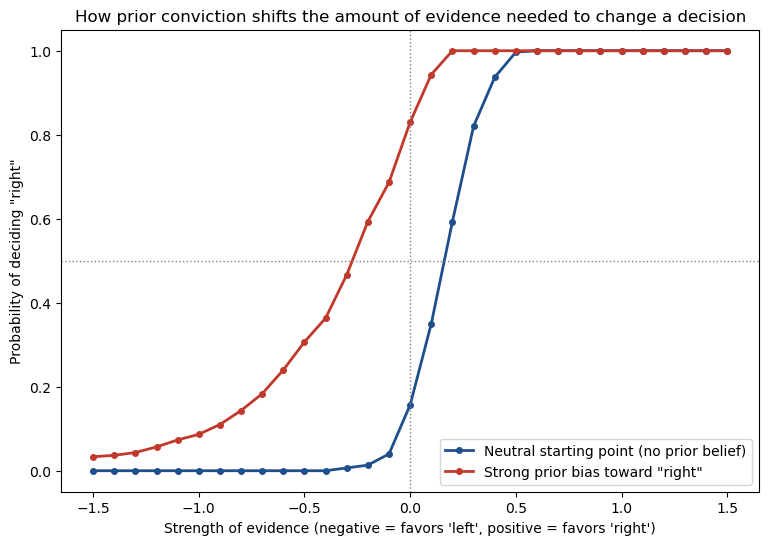

In [10]:
def pct_right(v, x0, n_trials=300):
    decisions = []
    for i in range(n_trials):
        _, _, decision, rt = simulate_ddm_biased(v=v, x0=x0, seed=i*7+1)
        decisions.append(decision)
    return np.mean([d == "right" for d in decisions])

drift_range = np.arange(-1.5, 1.55, 0.1)
neutral_curve = [pct_right(v, x0=0.0) for v in drift_range]
biased_curve = [pct_right(v, x0=0.9) for v in drift_range]

plt.figure(figsize=(9, 6))
plt.plot(drift_range, neutral_curve, marker='o', markersize=4, color='#1f4e8c',
         label='Neutral starting point (no prior belief)', linewidth=2)
plt.plot(drift_range, biased_curve, marker='o', markersize=4, color='#c0392b',
         label='Strong prior bias toward "right"', linewidth=2)
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.xlabel("Strength of evidence (negative = favors 'left', positive = favors 'right')")
plt.ylabel('Probability of deciding "right"')
plt.title("How prior conviction shifts the amount of evidence needed to change a decision")
plt.legend(loc='lower right')
plt.show()

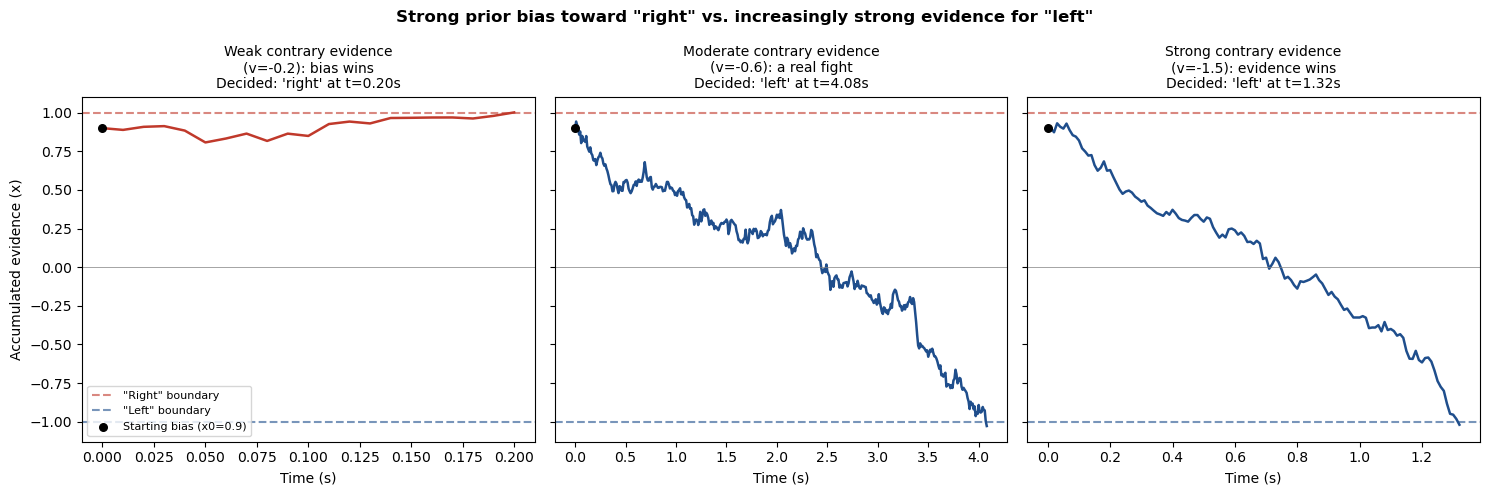

In [11]:
scenarios = [
    ("Weak contrary evidence\n(v=-0.2): bias wins", -0.2, 6),
    ("Moderate contrary evidence\n(v=-0.6): a real fight", -0.6, 1),
    ("Strong contrary evidence\n(v=-1.5): evidence wins", -1.5, 5),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (title, v, seed) in zip(axes, scenarios):
    t_trace, x_trace, decision, rt = simulate_ddm_biased(v=v, x0=0.9, seed=seed)
    color = '#c0392b' if decision == 'right' else '#1f4e8c'
    ax.plot(t_trace, x_trace, color=color, linewidth=1.8)
    ax.axhline(1.0, color='#c0392b', linestyle='--', alpha=0.6, label='"Right" boundary')
    ax.axhline(-1.0, color='#1f4e8c', linestyle='--', alpha=0.6, label='"Left" boundary')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.scatter([0], [0.9], color='black', zorder=5, s=30, label='Starting bias (x0=0.9)')
    ax.set_title(f"{title}\nDecided: '{decision}' at t={rt:.2f}s", fontsize=10)
    ax.set_xlabel("Time (s)")

axes[0].set_ylabel("Accumulated evidence (x)")
axes[0].legend(fontsize=8, loc='lower left')
plt.suptitle('Strong prior bias toward "right" vs. increasingly strong evidence for "left"', fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
def simulate_ddm_drift_bias(v_true, preferred_direction=1, dampen_factor=0.3,
                              sigma=0.3, boundary=1.0, dt=0.01, max_time=8.0, seed=None):
    """
    preferred_direction: +1 means agent prefers 'right', -1 means prefers 'left'
    dampen_factor: how much contrary momentary evidence gets reduced (0.3 = 30% strength)
    """
    if seed is not None:
        np.random.seed(seed)
    t = 0.0
    x = 0.0
    x_trace = [x]
    t_trace = [t]
    while abs(x) < boundary and t < max_time:
        raw_noise = sigma * np.sqrt(dt) * np.random.randn()
        momentary_evidence = v_true * dt + raw_noise
        # if this moment's evidence points AGAINST the preferred direction, dampen it
        if np.sign(momentary_evidence) != preferred_direction and momentary_evidence != 0:
            momentary_evidence *= dampen_factor
        x = x + momentary_evidence
        t = t + dt
        x_trace.append(x)
        t_trace.append(t)
    decision = "right" if x >= boundary else "left"
    return np.array(t_trace), np.array(x_trace), decision, t

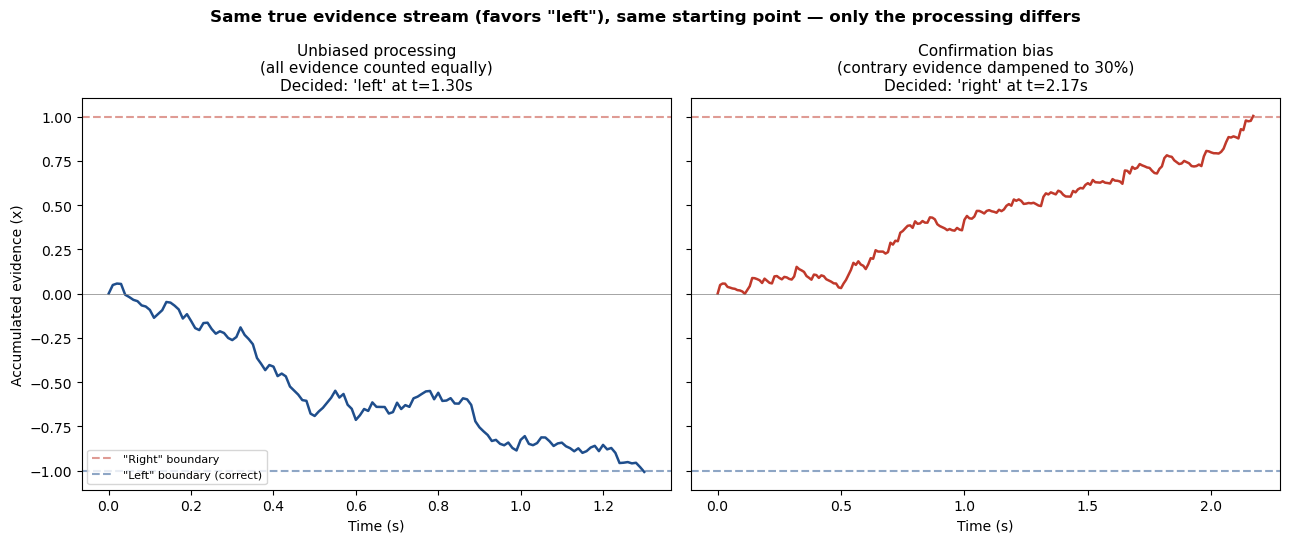

In [14]:
seed = 3
v_true = -0.5  # true evidence favors "left"

t_unbiased, x_unbiased, dec_unbiased, rt_unbiased = simulate_ddm_drift_bias(
    v_true, preferred_direction=1, dampen_factor=1.0, seed=seed)
t_biased, x_biased, dec_biased, rt_biased = simulate_ddm_drift_bias(
    v_true, preferred_direction=1, dampen_factor=0.3, seed=seed)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax, t_trace, x_trace, decision, rt, title, color in [
    (axes[0], t_unbiased, x_unbiased, dec_unbiased, rt_unbiased,
     "Unbiased processing\n(all evidence counted equally)", '#1f4e8c'),
    (axes[1], t_biased, x_biased, dec_biased, rt_biased,
     "Confirmation bias\n(contrary evidence dampened to 30%)", '#c0392b'),
]:
    ax.plot(t_trace, x_trace, color=color, linewidth=1.8)
    ax.axhline(1.0, color='#c0392b', linestyle='--', alpha=0.5, label='"Right" boundary')
    ax.axhline(-1.0, color='#1f4e8c', linestyle='--', alpha=0.5, label='"Left" boundary (correct)')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(f"{title}\nDecided: '{decision}' at t={rt:.2f}s", fontsize=11)
    ax.set_xlabel("Time (s)")

axes[0].set_ylabel("Accumulated evidence (x)")
axes[0].legend(fontsize=8, loc='lower left')
plt.suptitle('Same true evidence stream (favors "left"), same starting point — only the processing differs', fontweight='bold')
plt.tight_layout()
plt.show()